In [1]:
%cd ..
%load_ext autoreload
%autoreload 2

/home/dmatis/s/ssd/rl-optimization/turnus


In [2]:
import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [18]:
import time
import torch
from env import Env
import utils.graph_utils as graph_utils
from model import GCNPolicy
import torch.nn.functional as F

def e_greedy_eval(net: torch.nn.Module, env: Env):
    observation, mask = env.reset()
    terminal = False

    r_sum = 0
    while not terminal:
        logit, ext_value, int_value = net(observation)
        logit = torch.where(mask, logit, torch.tensor(-1e+8, device=logit.device))
        probs = F.softmax(logit, dim=-1)
        action = probs.argmax()
        observation, mask, reward, terminal, _ = env.step(action.item())
        r_sum += reward

    transform_rewards = env.reward_to_score_transformer()

    return observation, r_sum, env.vehicleID - 1

# device = torch.device("cuda:2" if torch.cuda.is_available() else "cpu")

results = {}
for i in range(50):
    net = None
    for problem in range(0,11):
        graph, optimal = graph_utils.load_problem(f'data/{problem}')
        env = Env(graph = graph, optimal = optimal, device=device)

        if net is None:
            net = GCNPolicy(env.state_space(), env.action_space()).to(device)
            print(f'Creating new model {i}')
        else:
            net.node_count = env.action_space()
        net.eval()

        if problem not in results:
            results[problem] = []

        start = time.time()
        observation, _, vehicles = e_greedy_eval(net, env)
        # observations, rewards, vehicles = search_results(net, env, 100)
        took = round(time.time() - start, 2)

        gap = vehicles / optimal

        results[problem].append([1 if gap <= 1.15 else 0, gap])

        print(f'Problem {problem} ({graph.num_nodes} nodes); \t agent: {vehicles} (opt. {optimal}) - it took {took}s')

Creating new model 0
Problem 0 (6 nodes); 	 agent: 2 (opt. 2) - it took 0.03s
Problem 1 (51 nodes); 	 agent: 6 (opt. 4) - it took 0.26s
Problem 2 (79 nodes); 	 agent: 8 (opt. 4) - it took 0.4s
Problem 3 (85 nodes); 	 agent: 8 (opt. 5) - it took 0.43s
Problem 4 (107 nodes); 	 agent: 9 (opt. 6) - it took 0.54s
Problem 5 (135 nodes); 	 agent: 13 (opt. 8) - it took 0.7s
Problem 6 (162 nodes); 	 agent: 15 (opt. 9) - it took 0.84s
Problem 7 (247 nodes); 	 agent: 23 (opt. 13) - it took 1.28s
Problem 8 (417 nodes); 	 agent: 40 (opt. 26) - it took 2.21s
Problem 9 (496 nodes); 	 agent: 41 (opt. 28) - it took 2.71s
Problem 10 (929 nodes); 	 agent: 75 (opt. 49) - it took 8.55s
Creating new model 1
Problem 0 (6 nodes); 	 agent: 2 (opt. 2) - it took 0.03s
Problem 1 (51 nodes); 	 agent: 5 (opt. 4) - it took 0.26s
Problem 2 (79 nodes); 	 agent: 8 (opt. 4) - it took 0.4s
Problem 3 (85 nodes); 	 agent: 8 (opt. 5) - it took 0.43s
Problem 4 (107 nodes); 	 agent: 9 (opt. 6) - it took 0.53s
Problem 5 (135 n

In [19]:
import numpy as np
res = np.array(list(results.values()))

Text(0.5, 1.0, 'Percentage of finding optimal solution across different problem sizes with random NN')

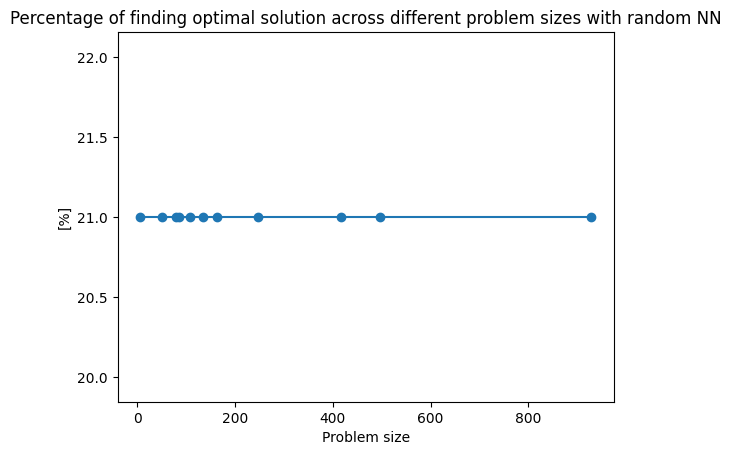

In [12]:
import matplotlib.pyplot as plt
import numpy as np

nodes = [6, 51, 79, 85, 107, 135, 162, 247, 417, 496, 929]

plt.plot(nodes, res[:, :, 0].sum(axis=1))
plt.scatter(nodes, res[:, :, 0].sum(axis=1))
plt.xlabel('Problem size')
plt.ylabel('[%]')
plt.title('Percentage of finding optimal solution across different problem sizes with random NN')

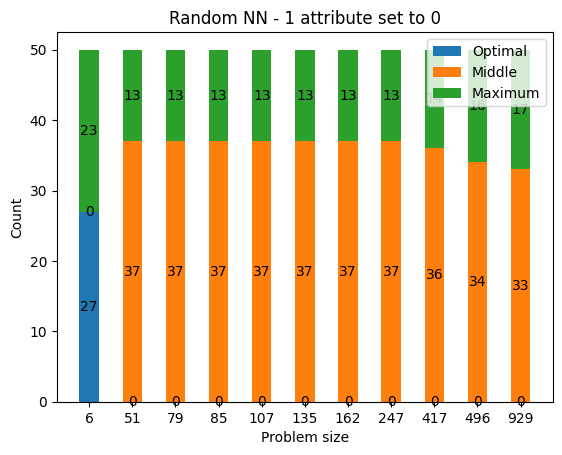

In [20]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots()
bottom = np.zeros(11)
width = 0.45

opt = (res[:, :, 1] <= 1.15).sum(axis=1)
maxi = (res[:, :, 1] >= (res[:, :, 1].max(axis=1) - 1)[:, np.newaxis]).sum(axis=1)
mid = 50 - (opt + maxi)

sols = {
    'Optimal': opt,
    'Middle': mid,
    'Maximum': maxi
}

for name, count in sols.items():
    p = ax.bar(list(map(str, nodes)), count, width, label=name, bottom=bottom)
    bottom += count

    ax.bar_label(p, label_type='center')

ax.set_title('Random NN - 1 attribute set to 0')
ax.set_ylabel('Count')
ax.set_xlabel('Problem size')
ax.legend()
plt.show()